
## Vizualizace dat v Pythonu

Tento notebook obsahuje příklady základních metod vizualizace dat:
- Histogram
- Jádrový histogram (KDE)
- Boxplot
- Violin plot
- Empirická distribuční funkce (EDF)
- P-P graf
- Q-Q graf

Používáme knihovny `matplotlib`, `scipy` a `statsmodels`.


### Histogram
Histogram je základní nástroj pro vizualizaci rozdělení dat. Rozděluje hodnoty do intervalů (tzv. binů) a zobrazuje četnost výskytu v každém intervalu.
- **Účel:** Rychlá představa o tvaru rozdělení (symetrie, špičatost, odlehlé hodnoty).
- **Poznámka:** Volba počtu binů ovlivňuje interpretaci – příliš málo binů zkresluje, příliš mnoho komplikuje.

Histogram data: (array([ 1,  4,  4,  4,  6, 10, 14, 27, 29, 39, 44, 63, 62, 88, 67, 86, 70,
       83, 56, 54, 50, 36, 28, 22, 16, 13,  9,  8,  4,  3]), array([-3.04614305, -2.85262645, -2.65910984, -2.46559324, -2.27207663,
       -2.07856003, -1.88504342, -1.69152682, -1.49801021, -1.3044936 ,
       -1.110977  , -0.91746039, -0.72394379, -0.53042718, -0.33691058,
       -0.14339397,  0.05012264,  0.24363924,  0.43715585,  0.63067245,
        0.82418906,  1.01770566,  1.21122227,  1.40473887,  1.59825548,
        1.79177209,  1.98528869,  2.1788053 ,  2.3723219 ,  2.56583851,
        2.75935511]))


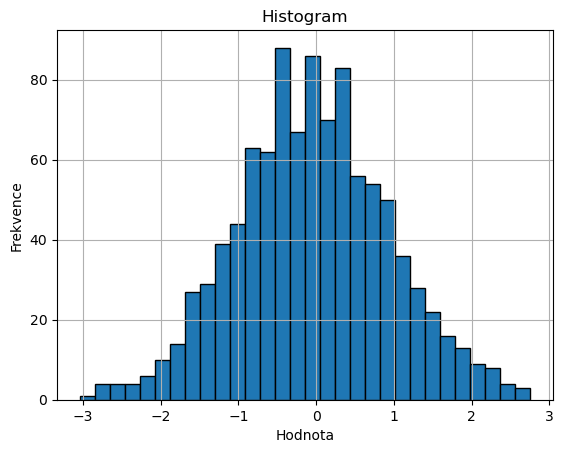

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
# Generování náhodných dat
n = 1000
np.random.seed(0)
data = np.random.randn(1000)
histogram = np.histogram(data, bins=30)
print("Histogram data:", histogram)
plt.hist(data, bins=30, edgecolor='black')
plt.title('Histogram')
plt.grid(True)
plt.xlabel('Hodnota')
plt.ylabel('Frekvence')
plt.show()


### Jádrový odhad hustoty (KDE)
KDE je metoda pro hladký odhad hustoty pravděpodobnosti na základě vzorku dat.
- **Princip:** Každý bod je „rozmazán“ pomocí jádrové funkce (např. Gaussovské) s šířkou pásma (bandwidth).
- **Výhoda:** Nepodléhá volbě binů, poskytuje hladký průběh.
- **Nevýhoda:** Citlivost na volbu šířky pásma – příliš malé → šum, příliš velké → ztráta detailů.

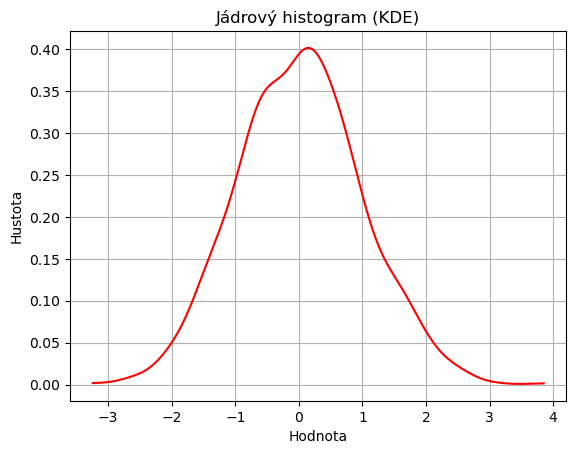

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Generování dat
np.random.seed(42)
data = np.random.normal(loc=0, scale=1, size=1000)

# Výpočet KDE
kde = stats.gaussian_kde(data)
x_vals = np.linspace(min(data), max(data), 1000)
y_vals = kde(x_vals)

# Vykreslení
plt.plot(x_vals, y_vals, color='red')
plt.title('Jádrový histogram (KDE)')
plt.xlabel('Hodnota')
plt.ylabel('Hustota')
plt.grid(True)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, Dropdown

np.random.seed(0)
data = np.random.normal(loc=0, scale=1, size=10)

kernels = {
    'Gaussovske': lambda x: np.exp(-0.5 * x**2) / np.sqrt(2 * np.pi),
    'Uniformni': lambda x: np.where(np.abs(x) <= 0.5, 1.0, 0.0),
    'Trojuhelnikove': lambda x: np.where(np.abs(x) <= 1, 1 - np.abs(x), 0.0),
    'Kosinove': lambda x: np.where(np.abs(x) <= 1, (np.pi/4) * np.cos((np.pi/2) * x), 0.0),
    'Epanechnikovovo': lambda x: np.where(np.abs(x) <= 1, 0.75 * (1 - x**2), 0.0)
}

def plot_kde(h=0.5, kernel_name='Gaussovske'):
    x_vals = np.linspace(-4, 4, 400)
    kde_vals = np.zeros_like(x_vals)
    kernel_func = kernels[kernel_name]

    plt.figure(figsize=(8, 4))
    for xi in data:
        kernel = kernel_func((x_vals - xi) / h) / h
        kde_vals += kernel
        plt.plot(x_vals, kernel, color='gray', linestyle='--', alpha=0.5)

    kde_vals /= len(data)
    plt.plot(x_vals, kde_vals, color='red', label='Density Estimate', linewidth=2)
    plt.plot(data, np.zeros_like(data), '|', color='blue', markersize=12, label='Data')
    # plt.title(f"Kernelovy odhad hustoty - jadro: {kernel_name}, h = {h}")
    plt.title(f"Kernel estimation - kernel: {kernel_name}, h = {h:.3f}")
    plt.xlabel("Value")
    plt.ylabel("Density")
    plt.legend()
    plt.grid(True)
    plt.show()

interact(plot_kde,
         h=FloatSlider(value=0.5, min=0.05, max=1.5, step=0.05, description='Sirka pasma'),
         kernel_name=Dropdown(options=list(kernels.keys()), description='Typ jadra'))


interactive(children=(FloatSlider(value=0.5, description='Sirka pasma', max=1.5, min=0.05, step=0.05), Dropdow…

<function __main__.plot_kde(h=0.5, kernel_name='Gaussovske')>

### Box plot
Boxplot je graf, který zobrazuje základní statistické charakteristiky rozdělení dat:
- **Prvky:** Medián, dolní a horní kvartil, „vousy“ (typicky 1,5× IQR) a odlehlé hodnoty.
- **Účel:** Porovnání rozdělení mezi skupinami, detekce odlehlých hodnot.


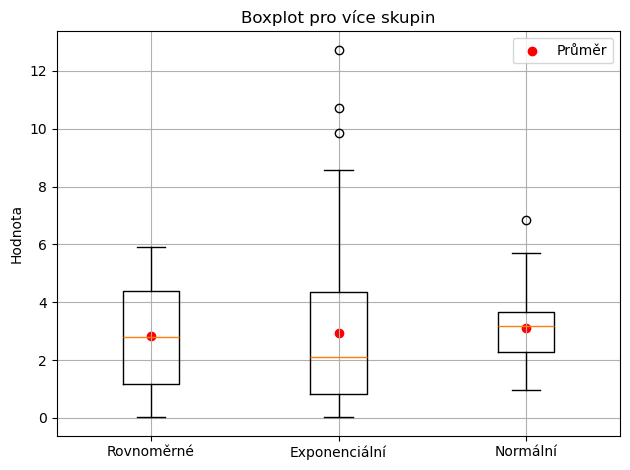

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Nastavení náhodného semínka
np.random.seed(42)
n = 100

# Generování dat
data_uniform = np.random.uniform(0, 6, n)
data_expon = np.random.exponential(3, n)
data_normal = np.random.normal(3, 1, n)

# Seskupení dat
data_groups = [data_uniform, data_expon, data_normal]
labels = ['Rovnoměrné', 'Exponenciální', 'Normální']

# Vykreslení boxplotu
plt.boxplot(data_groups, tick_labels=labels)

# Přidání průměrných hodnot jako červené body
means = [np.mean(group) for group in data_groups]
positions = range(1, len(data_groups) + 1)
plt.scatter(positions, means, color='red', marker='o', label='Průměr')

plt.title('Boxplot pro více skupin')
plt.ylabel('Hodnota')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


### Violin plot
Violin plot kombinuje boxplot s odhadem hustoty (KDE):
- **Prvky:** Symetrický tvar podle hustoty, uvnitř může být boxplot.
- **Účel:** Porovnání tvaru rozdělení mezi skupinami.

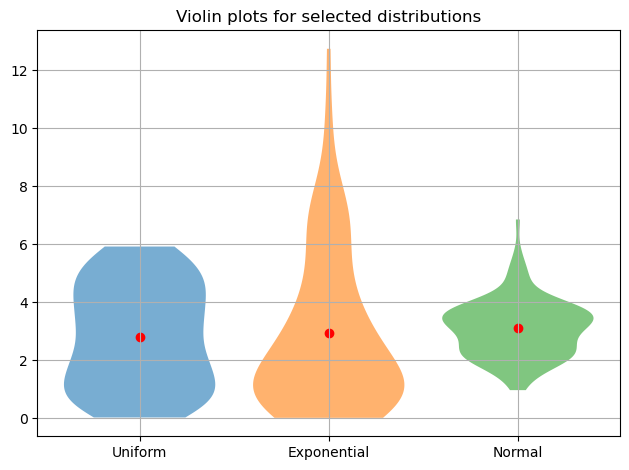

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# Generování dat pro tři různé skupiny
# Generování dat
np.random.seed(42)
n = 100
data_uniform = np.random.uniform(0, 6, n)
data_expon = np.random.exponential(3, n)
data_normal = np.random.normal(3, 1, n)

data_groups = [data_uniform, data_expon, data_normal]
labels = ['Uniform', 'Exponential', 'Normal']

# Vykreslení violin plotu pomocí KDE
fig, ax = plt.subplots()
positions = range(1, len(data_groups) + 1)

for pos, data in zip(positions, data_groups):
    kde = gaussian_kde(data)
    x_vals = np.linspace(min(data), max(data), 500)
    y_vals = kde(x_vals)
    y_vals = y_vals / y_vals.max() * 0.4  # škálování šířky

    ax.fill_betweenx(x_vals, pos - y_vals, pos + y_vals, alpha=0.6)
means = [np.mean(group) for group in data_groups]
positions = range(1, len(data_groups) + 1)
plt.scatter(positions, means, color='red', marker='o', label='Průměr')
ax.set_xticks(positions)
ax.set_xticklabels(labels)
ax.set_title('Violin plots for selected distributions')
plt.grid(True)
plt.tight_layout()
plt.show()

### Empirická distribuční funkce (EDF)
EDF je nárůstová funkce, která pro každou hodnotu ukazuje podíl dat menších nebo rovných této hodnotě.
- **Vlastnosti:** Neklesající, začíná v 0 a končí v 1.
- **Použití:** Porovnání s teoretickým rozdělením, vizualizace kumulativní pravděpodobnosti.

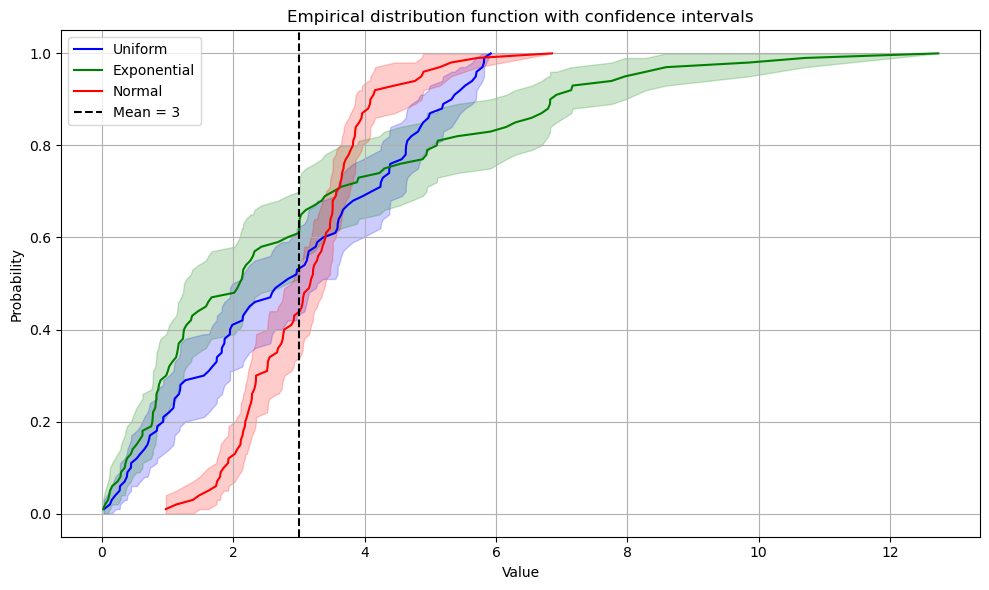

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Funkce pro výpočet EDF a bootstrap CI
def empirical_cdf_ci(data, alpha=0.05, n_bootstrap=1000):
    data_sorted = np.sort(data)
    n = len(data)
    cdf = np.arange(1, n+1) / n

    # Bootstrap EDFs
    bootstraps = np.zeros((n_bootstrap, n))
    for i in range(n_bootstrap):
        sample = np.random.choice(data, size=n, replace=True)
        sample_sorted = np.sort(sample)
        bootstraps[i] = np.searchsorted(sample_sorted, data_sorted, side='right') / n

    lower = np.percentile(bootstraps, 100 * alpha / 2, axis=0)
    upper = np.percentile(bootstraps, 100 * (1 - alpha / 2), axis=0)

    return data_sorted, cdf, lower, upper

# Generování dat
np.random.seed(42)
n = 100
data_uniform = np.random.uniform(0, 6, n)
data_expon = np.random.exponential(3, n)
data_normal = np.random.normal(3, 1, n)

# Výpočet EDF a CI
x_u, cdf_u, lower_u, upper_u = empirical_cdf_ci(data_uniform)
x_e, cdf_e, lower_e, upper_e = empirical_cdf_ci(data_expon)
x_n, cdf_n, lower_n, upper_n = empirical_cdf_ci(data_normal)

# Vykreslení
plt.figure(figsize=(10, 6))

plt.plot(x_u, cdf_u, label='Uniform', color='blue')
plt.fill_between(x_u, lower_u, upper_u, color='blue', alpha=0.2)

plt.plot(x_e, cdf_e, label='Exponential', color='green')
plt.fill_between(x_e, lower_e, upper_e, color='green', alpha=0.2)

plt.plot(x_n, cdf_n, label='Normal', color='red')
plt.fill_between(x_n, lower_n, upper_n, color='red', alpha=0.2)

# Přidání svislé čáry pro střední hodnotu
plt.axvline(x=3, color='black', linestyle='--', label='Mean = 3')

plt.title('Empirical distribution function with confidence intervals')
plt.xlabel('Value')
plt.ylabel('Probability')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### P-P graf (Probability-Probability plot)
Porovnává empirické a teoretické kumulativní pravděpodobnosti:
- **Interpretace:** Body blízko diagonály → dobrá shoda s modelem.
- **Použití:** Test normality nebo jiného teoretického rozdělení.

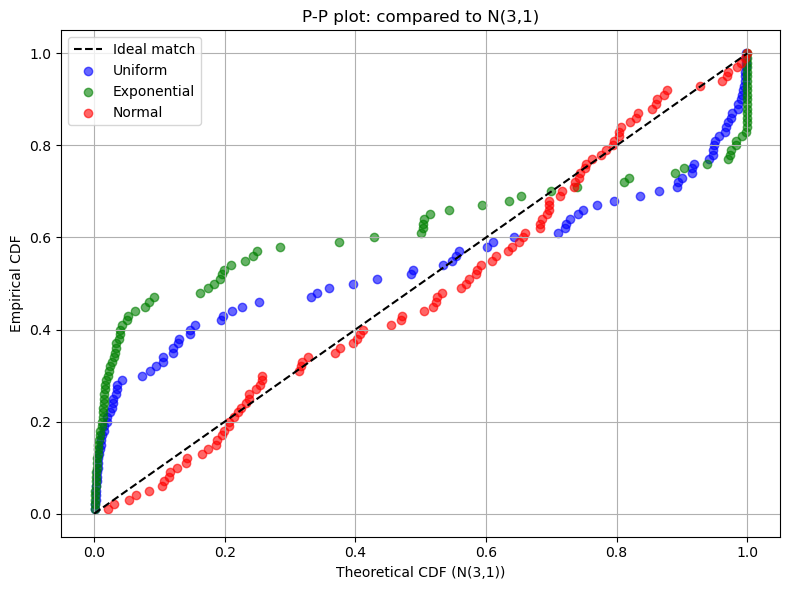

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Funkce pro výpočet P-P bodů
def pp_points(data, dist):
    data_sorted = np.sort(data)
    ecdf = np.arange(1, len(data_sorted)+1) / len(data_sorted)
    theoretical_cdf = dist.cdf(data_sorted)
    return theoretical_cdf, ecdf

# Generování dat
np.random.seed(42)
n = 100
data_uniform = np.random.uniform(0, 6, n)
data_expon = np.random.exponential(3, n)
data_normal = np.random.normal(3, 1, n)

# Porovnání s N(3,1)
norm_dist = stats.norm(loc=3, scale=1)

# Výpočet bodů pro P-P graf
x_u, y_u = pp_points(data_uniform, norm_dist)
x_e, y_e = pp_points(data_expon, norm_dist)
x_n, y_n = pp_points(data_normal, norm_dist)

# Vykreslení
plt.figure(figsize=(8, 6))
plt.plot([0, 1], [0, 1], 'k--', label='Ideal match')
plt.scatter(x_u, y_u, alpha=0.6, label='Uniform', color='blue')
plt.scatter(x_e, y_e, alpha=0.6, label='Exponential', color='green')
plt.scatter(x_n, y_n, alpha=0.6, label='Normal', color='red')
plt.xlabel('Theoretical CDF (N(3,1))')
plt.ylabel('Empirical CDF')
plt.title('P-P plot: compared to N(3,1)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Q-Q graf (Quantile-Quantile plot)
Porovnává empirické kvantily s teoretickými kvantily:
- **Interpretace:** Body na diagonále → data odpovídají teoretickému rozdělení.
- **Použití:** Diagnostika odchylek od normality (zakřivení → špičatost, odlehlé body → extrémy).

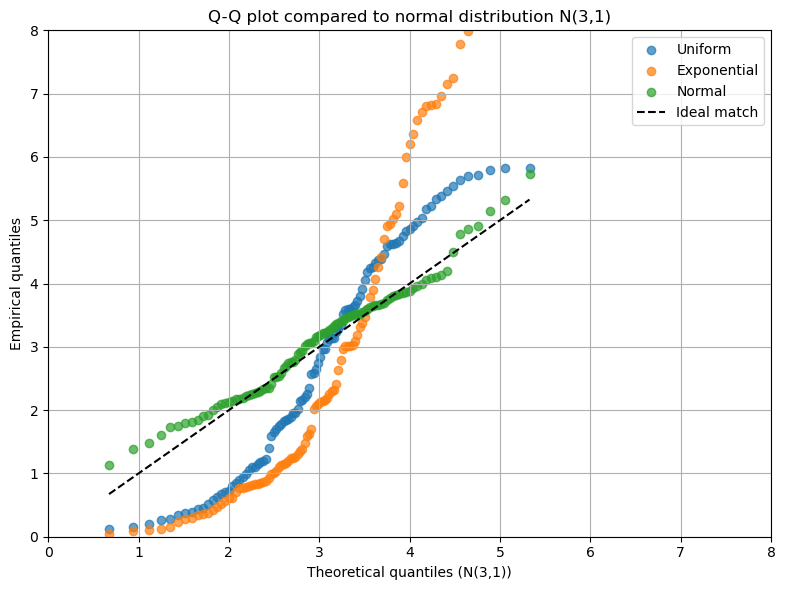

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Nastavení random seed
np.random.seed(42)

# Generování dat pro tři rozdělení
n = 100
data_uniform = np.random.uniform(0, 6, n)
data_expon = np.random.exponential(3, n)
data_normal = np.random.normal(3, 1, n)

# Výpočet teoretických kvantilů normálního rozdělení N(3,1)
quantiles = np.linspace(0.01, 0.99, 100)
theoretical_quantiles = stats.norm.ppf(quantiles, loc=3, scale=1)

# Výpočet empirických kvantilů
empirical_uniform = np.quantile(data_uniform, quantiles)
empirical_expon = np.quantile(data_expon, quantiles)
empirical_normal = np.quantile(data_normal, quantiles)

# Vykreslení Q-Q grafu
plt.figure(figsize=(8, 6))
plt.scatter(theoretical_quantiles, empirical_uniform, label='Uniform', alpha=0.7)
plt.scatter(theoretical_quantiles, empirical_expon, label='Exponential', alpha=0.7)
plt.scatter(theoretical_quantiles, empirical_normal, label='Normal', alpha=0.7)
plt.plot(theoretical_quantiles, theoretical_quantiles, 'k--', label='Ideal match')
plt.title('Q-Q plot compared to normal distribution N(3,1)')
plt.xlabel('Theoretical quantiles (N(3,1))')
plt.ylabel('Empirical quantiles')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.xlim(0, 8)
plt.ylim(0, 8)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import ipywidgets as widgets
from IPython.display import display, clear_output

# Funkce pro generování dat podle zvoleného rozdělení
def generate_data(distribution, size=1000):
    if distribution == 'Rovnoměrné':
        return np.random.uniform(low=0, high=1, size=size)
    elif distribution == 'Exponenciální':
        return np.random.exponential(scale=1.0, size=size)
    elif distribution == 'Normální':
        return np.random.normal(loc=0, scale=1, size=size)

# Funkce pro vykreslení všech grafů
def plot_all(data):
    kde = stats.gaussian_kde(data)
    x_vals = np.linspace(min(data), max(data), 1000)
    y_vals = kde(x_vals)

    fig, axs = plt.subplots(3, 2, figsize=(12, 12))

    # Histogram
    axs[0, 0].hist(data, bins=30, color='skyblue', edgecolor='black')
    axs[0, 0].set_title('Histogram')

    # KDE
    axs[0, 1].plot(x_vals, y_vals, color='red')
    axs[0, 1].set_title('Jádrový histogram (KDE)')

    # Boxplot
    axs[1, 0].boxplot(data, vert=False)
    axs[1, 0].set_title('Boxplot')

    # Violin plot (ručně pomocí KDE)
    axs[1, 1].fill_betweenx(x_vals, 0, y_vals, color='purple', alpha=0.5)
    axs[1, 1].set_title('Violin plot')

    # Empirická distribuční funkce
    sorted_data = np.sort(data)
    edf = np.arange(1, len(sorted_data)+1) / len(sorted_data)
    axs[2, 0].plot(sorted_data, edf, marker='.', linestyle='none')
    axs[2, 0].set_title('Empirická distribuční funkce')

    # Q-Q graf
    stats.probplot(data, dist="norm", plot=axs[2, 1])
    axs[2, 1].set_title('Q-Q graf')

    plt.tight_layout()
    plt.show()

# Interaktivní ovládání
selector = widgets.Dropdown(
    options=['Rovnoměrné', 'Exponenciální', 'Normální'],
    value='Normální',
    description='Rozdělení:',
    style={'description_width': 'initial'}
)

output = widgets.Output()

# Callback funkce
def update_plot(change):
    with output:
        clear_output(wait=True)
        data = generate_data(selector.value)
        plot_all(data)

selector.observe(update_plot, names='value')

# Zobrazení
display(selector, output)
update_plot(None)


Dropdown(description='Rozdělení:', index=2, options=('Rovnoměrné', 'Exponenciální', 'Normální'), style=Descrip…

Output()